# Actividad 7
## Programación y matemáticas para la ciencia de datos
## Edilberto Antonio Gómez García

In [1]:
import numpy as np
import pandas as pd
import random

## 7.9

Create an array containing the values 1–15, reshape it into a 3-by-5 array, then use indexing and slicing techniques to perform each of the following operations:

a) Select row 2.

b) Select column 5.

c) Select rows 0 and 1.

d) Select columns 2–4.

e) Select the element that is in row 1 and column 4.

f) Select all elements from rows 1 and 2 that are in columns 0, 2 and 4.

In [2]:
array = np.arange(1,16).reshape((3,5))
array

array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10],
       [11, 12, 13, 14, 15]])

In [3]:
# a)
array[1]

array([ 6,  7,  8,  9, 10])

In [4]:
# b)
array[:,4]

array([ 5, 10, 15])

In [7]:
# c)
array[:2]

array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10]])

In [10]:
# d)
array[:,1:4]

array([[ 2,  3,  4],
       [ 7,  8,  9],
       [12, 13, 14]])

In [17]:
# e)
array[1,4]

np.int64(10)

In [18]:
# f)
array[1:3,0:5:2]

array([[ 6,  8, 10],
       [11, 13, 15]])

## 7.13

Research the NumPy broadcasting rules, then create your own arrays to test the rules.

### Reglas de Broadcasting en NumPy

Las reglas del broadcasting que numpy sigue sirven para que la libreria decida si puede sumar, restar o multiplicar 2 arreglos, sigue estos 3 pasos:

1.- Obtiene la forma (shape) de cada arreglo, en dado caso que sus dimensiones no coincidan, es decir, una sea más chica que otra, las alinea a la derecha, para que sus últimas dimensiones coincidan, por ejemplo: A dimension de 2 de tamaño (4x2) y B dimension de 3 tamaño (5x1x2), en dado caso que existan hueco numpy los rellana con 1.

Alineación:

A:   x 4 x 2 <-- alineó a A a la derecha

B: 5 x 1 x 2

Relleno:

A: 1 x 4 x 2 <-- rellenó a A

B: 5 x 1 x 2

2.-  Va comparando de derecha a izquierda las columnas, y todas las comparaciones deben de cumplir con una de las siguientes reglas para que sea válida la operación, si una comparación es incorrecta no se realizará la operación, dichas reglas son:

- Los dos números deben ser exactamente iguales.
- Si no son exactamente iguales, al menos uno de ellos debe ser 1.

A: 1 x 4 x 2 

B: 5 x 1 x 2

Comparación 2 con 2 -> pasa, 4 con 1 -> pasa, 1 con 5 -> pasa, por lo tanto la operación se puede realizar 

3.- Si las comparaciones salieron exitosas, las dimensiones que tengan 1 se estiran para realizar la operación exitosa. 

Por ejemplo: Matriz A de dimension 2, tamaño 3x3; Matriz B de dimension 1 de tamaño 3. Opración sumar A con B. Pasos:

Alineación:

A: 3 x 3 

B:   x 3 <-- alineó a A a la derecha

Relleno:

A: 3 x 3 

B: 1 x 3 <-- rellenó a B

Comparación:

3 con 3 pasa, 3 con 1 pasa. Operación válida

Estiramiento, sea por ejemplo A y B:

```
A                     B
[ [1, 2, 3],          [ [10, 20, 30] ]
  [4, 5, 6],
  [7, 8, 9] ]
```
Se estirará a B
```
A                     B
[ [1, 2, 3],          [ [10, 20, 30], 
  [4, 5, 6],            [10, 20, 30],
  [7, 8, 9] ]           [10, 20, 30] ]
```
Suma A y B
```
[ [11, 22, 33],
  [14, 25, 36],
  [17, 28, 39] ]
```

Ejemplo donde falla:
Matriz A de dimension 4, tamaño 3x4x5x2; Matriz B de dimension 2 de tamaño 3x2. Opración sumar A con B. Pasos:

Alineación:

A: 3 x 4 x 5 x 2 

B:  x x 3 x 2 <-- alineó a A a la derecha

Relleno:

A: 3 x 4 x 5 x 2 

B: 1 x 1 x 3 x 2  <-- rellenó a B

Comparación:

2 con 2 pasa, 5 con 3 no pasa. Operación no válida, aunque las comparaciones siguiente sean válidas.


## 7.20

In this chapter, we used %timeit to compare the average execution
times of generating a list of 6,000,000 random die rolls vs. generating an array of
6,000,000 random die rolls. Though we saw approximately two orders of magnitude performance
improvement with array, we generated the list and the array using two different random-
number generators and different techniques for building each collection. If you use the
same techniques we showed to generate a one-element list and a one-element array, creating
the list is slightly faster. Repeat the %timeit operations for one-element collections. Then do
it again for 10, 100, 1000, 10,000, 100,000, and 1,000,000 elements and compare the results
on your system. The table below shows the results on our system, with measurements
in nanoseconds (ns), microseconds (μs), milliseconds (ms) and seconds (s).

![tabla_tiempos](tabla_tiempos.png)

This analysis shows why %timeit is convenient for quick performance studies. However,
you also need to develop performance-analysis wisdom. Many factors can affect performance—
the underlying hardware, the operating system, the interpreter or compiler
you’re using, the other applications running on your computer at the same time, and
many more. The way we thought about performance over the years is changing rapidly
now with big data, data analytics and artificial intelligence. As we head into the AI portion
of the book, you’ll place enormous performance demands on your system, so it’s
always good to be thinking about performance issues.

In [15]:
    iteraciones = [1, 10, 100, 1000, 10000, 100000, 1000000]

    tiempo_list = []
    tiempo_array = []

    for i in iteraciones:

        lista = %timeit -q -o [random.randrange(1, 7) for _ in range(i)]
        tiempo_list.append(lista)

        array = %timeit -q -o np.random.randint(1, 7, i)
        tiempo_array.append(array)

In [3]:
tiempo_array

[<TimeitResult : 14.6 μs ± 294 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)>,
 <TimeitResult : 14.7 μs ± 308 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)>,
 <TimeitResult : 16 μs ± 72.7 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)>,
 <TimeitResult : 30.2 μs ± 243 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)>,
 <TimeitResult : 170 μs ± 954 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)>,
 <TimeitResult : 1.56 ms ± 12.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)>,
 <TimeitResult : 16.6 ms ± 105 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)>]

In [12]:
tiempo_array[0].all_runs

[1.429545599999983,
 1.4535032999999657,
 1.530331799999999,
 1.457334899999978,
 1.451211599999965,
 1.4565946000000167,
 1.4532897999999932]

In [7]:
print(dir(tiempo_array[0]))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_precision', '_repr_pretty_', 'all_runs', 'average', 'best', 'compile_time', 'loops', 'repeat', 'stdev', 'timings', 'worst']


In [16]:
str_list = [str(tiempo) for tiempo in tiempo_list]
str_array = [str(tiempo) for tiempo in tiempo_array]

In [17]:
pd.DataFrame({'iteraciones': iteraciones,
              'Ejecucion listas': str_list,
              'Ejecucion array': str_array})

,iteraciones,Ejecucion listas,Ejecucion array
0,1,1.07 μs ± 14.1 ns per loop (mean ± std. dev. o...,14.4 μs ± 253 ns per loop (mean ± std. dev. of...
1,10,8.2 μs ± 98 ns per loop (mean ± std. dev. of 7...,14.4 μs ± 76.7 ns per loop (mean ± std. dev. o...
2,100,78.2 μs ± 628 ns per loop (mean ± std. dev. of...,15.7 μs ± 124 ns per loop (mean ± std. dev. of...
3,1000,823 μs ± 36 μs per loop (mean ± std. dev. of 7...,30.2 μs ± 661 ns per loop (mean ± std. dev. of...
4,10000,8.07 ms ± 122 μs per loop (mean ± std. dev. of...,170 μs ± 1.33 μs per loop (mean ± std. dev. of...
5,100000,78.5 ms ± 956 μs per loop (mean ± std. dev. of...,1.55 ms ± 10.5 μs per loop (mean ± std. dev. o...
6,1000000,812 ms ± 9.39 ms per loop (mean ± std. dev. of...,16.8 ms ± 374 μs per loop (mean ± std. dev. of...


In [ ]:
average_list = [tiempo.average for tiempo in tiempo_list]
average_array = [tiempo.average for tiempo in tiempo_array]

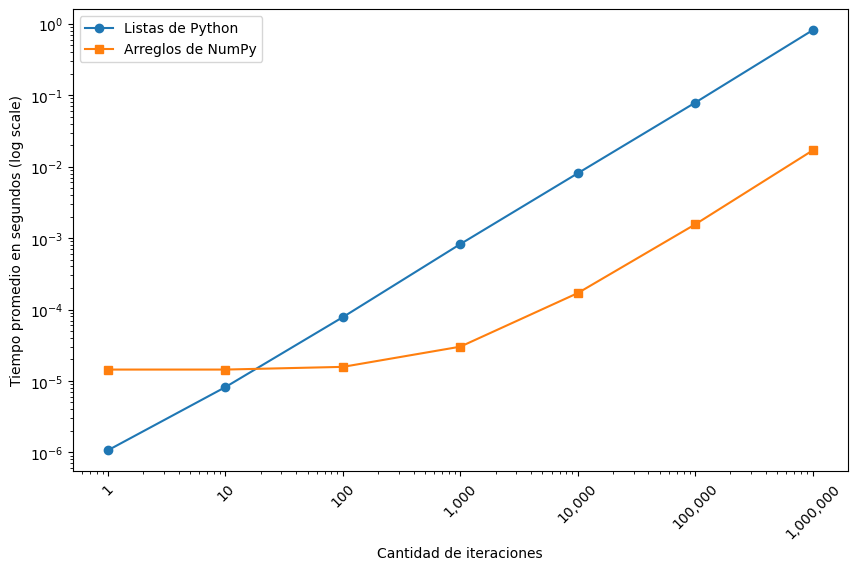

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.plot(iteraciones, average_list, marker='o', label='Listas de Python')
plt.plot(iteraciones, average_array, marker='s', label='Arreglos de NumPy')

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Iteraciones')
plt.ylabel('Tiempo promedio en segundos (log scale)')

etiquetas = [f"{num:,}" for num in iteraciones]
plt.xticks(iteraciones, etiquetas, rotation=45)

plt.legend()

## 7.22

Perform the following tasks with pandas Series:

a) Create a Series from the list [7, 11, 13, 17].

b) Create a Series with five elements that are all 100.0.

c) Create a Series with 20 elements that are all random numbers in the range 0 to
100. Use method describe to produce the Series’ basic descriptive statistics.

d) Create a Series called temperatures of the floating-point values 98.6, 98.9,
100.2 and 97.9. Using the index keyword argument, specify the custom indices
'Julie', 'Charlie', 'Sam' and 'Andrea'.

e) Form a dictionary from the names and values in Part (d), then use it to initialize
a Series.

In [ ]:
# a)
lista = [7, 11, 13, 17]
serie = pd.Series(lista)
serie

0     7
1    11
2    13
3    17
dtype: int64

In [ ]:
# b)
serie = pd.Series([100.0]*5)
serie

0    100.0
1    100.0
2    100.0
3    100.0
4    100.0
dtype: float64

In [3]:
# c)
serie = pd.Series(np.random.randint(100, size=20))
serie.describe()

count    20.000000
mean     50.450000
std      25.789584
min       2.000000
25%      38.500000
50%      50.500000
75%      68.000000
max      95.000000
dtype: float64

In [ ]:
# d)
temperatures = pd.Series([98.6, 98.9, 100.2, 97.9], index=['Julie', 'Charlie', 'Sam', 'Andrea'])
temperatures

Julie       98.6
Charlie     98.9
Sam        100.2
Andrea      97.9
dtype: float64

In [6]:
# e)
diccionario = {temp: name for temp, name in temperatures.items()}
temperatures_2 = pd.Series(diccionario.values(), index=diccionario.keys())
temperatures_2


Julie       98.6
Charlie     98.9
Sam        100.2
Andrea      97.9
dtype: float64

## 7.23

Perform the following tasks with pandas DataFrames:

a) Create a DataFrame named temperatures from a dictionary of three temperature
readings each for 'Maxine', 'James' and 'Amanda'.

b) Recreate the DataFrame temperatures in Part (a) with custom indices using
the index keyword argument and a list containing 'Morning', 'Afternoon'
and 'Evening'.

c) Select from temperatures the column of temperature readings for 'Maxine'.

d) Select from temperatures the row of 'Morning' temperature readings.

e) Select from temperatures the rows for 'Morning' and 'Evening' temperature
readings.

f) Select from temperatures the columns of temperature readings for 'Amanda'
and 'Maxine'.

g) Select from temperatures the elements for 'Amanda' and 'Maxine' in the
'Morning' and 'Afternoon'.

h) Use the describe method to produce temperatures’ descriptive statistics.

i) Transpose temperatures.

j) Sort temperatures so that its column names are in alphabetical order.

In [13]:
# a)
datos = {'Maxine' : np.random.uniform(36, 37, size=3),
        'James' : np.random.uniform(36, 37, size=3),
        'Amanda' : np.random.uniform(36, 37, size=3)}

temperaturas = pd.DataFrame(datos)
temperaturas

,Maxine,James,Amanda
0,36.592145,36.441559,36.857596
1,36.089959,36.076811,36.888742
2,36.319222,36.206764,36.713579


In [14]:
# b)
temperaturas = pd.DataFrame(datos, index=['Morning', 'Afternoon', 'Evening'])
temperaturas

,Maxine,James,Amanda
Morning,36.592145,36.441559,36.857596
Afternoon,36.089959,36.076811,36.888742
Evening,36.319222,36.206764,36.713579


In [15]:
# c)
temperaturas['Maxine']

Morning      36.592145
Afternoon    36.089959
Evening      36.319222
Name: Maxine, dtype: float64

In [16]:
# d)
temperaturas.loc['Morning']

Maxine    36.592145
James     36.441559
Amanda    36.857596
Name: Morning, dtype: float64

In [17]:
# e)
temperaturas.loc[['Morning', 'Evening']]

,Maxine,James,Amanda
Morning,36.592145,36.441559,36.857596
Evening,36.319222,36.206764,36.713579


In [ ]:
# f)
temperaturas[['Amanda', 'Maxine']]

,Amanda,Maxine
Morning,36.857596,36.592145
Afternoon,36.888742,36.089959
Evening,36.713579,36.319222


In [19]:
# g)
temperaturas[['Amanda', 'Maxine']].loc[['Morning', 'Afternoon']]

,Amanda,Maxine
Morning,36.857596,36.592145
Afternoon,36.888742,36.089959


In [20]:
# h)
temperaturas.describe()

,Maxine,James,Amanda
count,3.000000,3.000000,3.000000
mean,36.333775,36.241711,36.819972
std,0.251409,0.184869,0.093446
min,36.089959,36.076811,36.713579
25%,36.204591,36.141787,36.785587
50%,36.319222,36.206764,36.857596
75%,36.455683,36.324162,36.873169
max,36.592145,36.441559,36.888742


In [21]:
# i)
temperaturas.T

,Morning,Afternoon,Evening
Maxine,36.592145,36.089959,36.319222
James,36.441559,36.076811,36.206764
Amanda,36.857596,36.888742,36.713579


In [25]:
# j)
temperaturas.sort_index(axis=1,ascending=True)

,Amanda,James,Maxine
Morning,36.857596,36.441559,36.592145
Afternoon,36.888742,36.076811,36.089959
Evening,36.713579,36.206764,36.319222
